# Decision Tree Learning — Optimasi Tambahan
## Loan Approval Classification — Task 2 Seleksi Lab IB

Notebook ini membahas empat variasi tambahan pada single decision tree untuk model klasifikasi pinjaman. Fokus utamanya adalah memperbaiki cara split fitur kategorik, menyeimbangkan bias pada fitur dengan banyak nilai unik, dan memilih parameter pruning yang lebih stabil.

1. Split subset untuk fitur kategorik, bukan threshold angka biasa.
2. Gain Ratio sebagai kriteria split untuk mengurangi bias fitur dengan kardinalitas tinggi.
3. Split berbasis chi-square yang mengikuti pendekatan CHAID.
4. Cost-complexity pruning berbasis cross-validation untuk memilih alpha yang lebih stabil.

Semua teknik ini tetap berada dalam satu decision tree, tanpa ensemble atau model tambahan.

Referensi:
- Breiman et al. (1984). Classification and Regression Trees.
- Quinlan (1993). C4.5: Programs for Machine Learning.
- Kass (1980). An Exploratory Technique for Investigating Large Quantities of Categorical Data.

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
source_dir = project_root / 'src' / 'dtl_lr_svm'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from dtl import DecisionTreeCART, DecisionTreeCARTAdvanced, cv_cost_complexity_pruning

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')


ModuleNotFoundError: No module named 'decision_tree_advanced'

## 1. Load & Preprocessing

Menggunakan preprocessing yang sama seperti notebook utama (outlier capping, feature engineering, label encoding) agar hasil bisa dibandingkan apple-to-apple.

In [ ]:
train_raw = pd.read_csv('../../train.csv')
test_raw = pd.read_csv('../../test.csv')

train_capped = cap_outliers(train_raw, 'person_age', upper=80)
test_capped = cap_outliers(test_raw, 'person_age', upper=80)

train_fe = add_engineered_features(train_capped)
test_fe = add_engineered_features(test_capped)

cat_cols = ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
train_enc, encoding_map = encode_categoricals(train_fe, cat_cols)
test_enc, _ = encode_categoricals(test_fe, cat_cols, mapping=encoding_map)

feature_cols = [c for c in train_enc.columns if c not in ('person_id', 'loan_status')]
X = train_enc[feature_cols].values
y = train_enc['loan_status'].values

X_kaggle_test = test_enc[feature_cols].values
kaggle_test_ids = test_enc['person_id'].values

cat_indices = [feature_cols.index(c) for c in cat_cols]

print(f'Jumlah fitur: {len(feature_cols)}')
print(f'Fitur kategorik: {[feature_cols[i] for i in cat_indices]}')


Jumlah fitur: 15
Fitur kategorik (subset split): ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']


In [3]:
train_idx, val_idx, test_idx = stratified_train_val_test_split(
    X, y, val_size=0.15, test_size=0.15, random_state=42
)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')


Train: 20160, Val: 4320, Test: 4320


## 2. Baseline Pembanding: Model dari Notebook Utama

Sebagai titik acuan, kita pakai hasil terbaik dari `01_decision_tree.ipynb`: CART biner standar dengan kriteria terbaik (Gini/Entropy) + pre-pruning/post-pruning yang sudah dituning + class weighting.

In [4]:
baseline_model = DecisionTreeCART(
    criterion='gini', max_depth=6, min_samples_leaf=20, class_weight='balanced'
)
baseline_model.fit(X_train, y_train, feature_names=feature_cols)

pred_val_baseline = baseline_model.predict(X_val)
baseline_f1_val = macro_f1_score(y_val, pred_val_baseline)
print(f'Baseline (CART biner, Gini, pre-pruned) - Macro F1 (val): {baseline_f1_val:.4f}')


Baseline (CART biner, Gini, pre-pruned) - Macro F1 (val): 0.8510


## 3. Teknik #1 + #2: Optimal Categorical Split dengan Gain Ratio

`DecisionTreeCARTAdvanced` mendukung dua hal baru sekaligus: fitur kategorik di-split dengan **subset partitioning optimal** (bukan threshold numerik dari label encoding), dan kriteria split bisa memakai **Gain Ratio** (C4.5-style) untuk mengurangi bias terhadap fitur numerik berkardinalitas tinggi.

In [5]:
t0 = time.time()
clf_gain_ratio = DecisionTreeCARTAdvanced(
    criterion='gain_ratio', max_depth=6, min_samples_leaf=20,
    class_weight='balanced', categorical_features=cat_indices
)
clf_gain_ratio.fit(X_train, y_train, feature_names=feature_cols)
fit_time = time.time() - t0

pred_val_gr = clf_gain_ratio.predict(X_val)
f1_gr = macro_f1_score(y_val, pred_val_gr)

print(f'Gain Ratio + Categorical Split - Macro F1 (val): {f1_gr:.4f} (fit time: {fit_time:.2f}s)')
print(f'Depth: {clf_gain_ratio.get_depth()}, Leaves: {clf_gain_ratio.get_n_leaves()}')


Gain Ratio + Categorical Split - Macro F1 (val): 0.8648 (fit time: 0.24s)
Depth: 6, Leaves: 21


In [ ]:
print(clf_gain_ratio.export_text())


[previous_loan_defaults_on_file in {1.0}] (n=20160.0)
  ├─ True: Leaf -> class=0 (n=6595.7, dist=[0: 6595.7, 1: 0.0])
  └─ False: [loan_to_income_recompute <= 0.2472] (n=13564.3)
    ├─ True: [loan_int_rate <= 14.4150] (n=9557.7)
      ├─ True: [person_income <= 24451.5000] (n=6511.8)
        ├─ True: [loan_to_income_recompute <= 0.1207] (n=687.2)
          ├─ True: [loan_to_income_recompute <= 0.0773] (n=95.5)
            ├─ True: Leaf -> class=1 (n=46.6, dist=[0: 3.9, 1: 42.8])
            └─ False: Leaf -> class=1 (n=48.9, dist=[0: 17.4, 1: 31.5])
          └─ False: Leaf -> class=1 (n=591.8, dist=[0: 0.0, 1: 591.8])
        └─ False: [person_home_ownership in {2.0}] (n=5824.6)
          ├─ True: [person_income <= 29889.0000] (n=198.3)
            ├─ True: Leaf -> class=0 (n=20.2, dist=[0: 18.0, 1: 2.2])
            └─ False: Leaf -> class=0 (n=178.1, dist=[0: 178.1, 1: 0.0])
          └─ False: [credit_score <= 509.5000] (n=5626.3)
            ├─ True: Leaf -> class=1 (n=54.6, dist

Pada fitur kategorik, pola split biasanya muncul sebagai subset seperti `[fitur in {A, B}]` bukan hanya batas angka. Ini menandakan model memakai pemisahan kategori yang lebih sesuai dengan data.

## 4. Teknik #3: Perbandingan Kriteria Split — Gini vs Entropy vs Gain Ratio vs Chi-Square

Kita bandingkan keempat kriteria split secara sistematis menggunakan **Stratified K-Fold CV** pada training set (semua memakai categorical subset split, supaya perbandingan murni soal kriteria split-nya saja).

In [7]:
def cv_evaluate_advanced(X, y, criterion, max_depth, min_samples_leaf, class_weight,
                          categorical_features, n_splits=5, n_repeats=1):
    scores = []
    for tr_idx, va_idx in stratified_k_fold(y, n_splits=n_splits, random_state=42, n_repeats=n_repeats):
        clf = DecisionTreeCARTAdvanced(
            criterion=criterion, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            class_weight=class_weight, categorical_features=categorical_features
        )
        clf.fit(X[tr_idx], y[tr_idx])
        pred = clf.predict(X[va_idx])
        scores.append(macro_f1_score(y[va_idx], pred))
    return np.array(scores)

criteria_results = {}
for criterion in ['gini', 'entropy', 'gain_ratio', 'chi2']:
    scores = cv_evaluate_advanced(
        X_train, y_train, criterion=criterion, max_depth=8, min_samples_leaf=15,
        class_weight='balanced', categorical_features=cat_indices, n_splits=5
    )
    criteria_results[criterion] = scores
    print(f'{criterion:12s} - Macro F1 CV: {scores.mean():.4f} +/- {scores.std():.4f}')


gini         - Macro F1 CV: 0.8401 +/- 0.0094


entropy      - Macro F1 CV: 0.8574 +/- 0.0065


gain_ratio   - Macro F1 CV: 0.8246 +/- 0.0389


chi2         - Macro F1 CV: 0.8401 +/- 0.0094


/tmp/ipykernel_517/3850177677.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


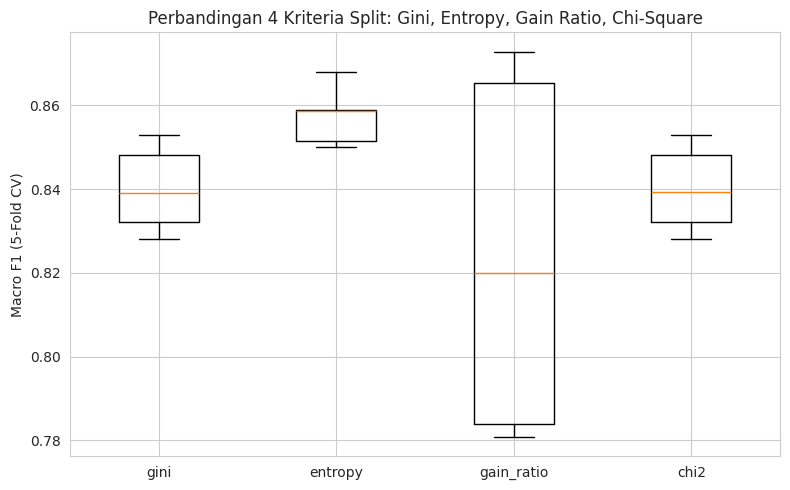

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
labels = list(criteria_results.keys())
data = [criteria_results[k] for k in labels]
ax.boxplot(data, labels=labels)
ax.set_ylabel('Macro F1 (5-Fold CV)')
ax.set_title('Perbandingan 4 Kriteria Split: Gini, Entropy, Gain Ratio, Chi-Square')
plt.tight_layout()
plt.show()


In [9]:
BEST_CRITERION_ADV = max(criteria_results, key=lambda k: criteria_results[k].mean())
print(f'Kriteria terbaik (dengan categorical subset split): {BEST_CRITERION_ADV}')
print(f'Macro F1 CV: {criteria_results[BEST_CRITERION_ADV].mean():.4f}')


Kriteria terbaik (dengan categorical subset split): entropy
Macro F1 CV: 0.8574


**Interpretasi:**
- **Gain Ratio** secara teori dirancang untuk menyeimbangkan bias terhadap fitur dengan banyak nilai unik (seperti `person_income`, `loan_amnt`) — relevan di dataset ini karena beberapa fitur numerik punya kardinalitas sangat tinggi.
- **Chi-square (CHAID-style)** mengukur signifikansi statistik asosiasi, bisa lebih robust terhadap split yang "kebetulan" bagus di data kecil, tapi sensitif terhadap ukuran sampel per kategori.
- **Gini** dan **Entropy** adalah baseline information-theoretic standar.

Kriteria dengan performa CV terbaik dipilih untuk model final di bagian selanjutnya.

## 5. Teknik #4: Cost-Complexity Pruning Berbasis CV

Pencarian `ccp_alpha` dilakukan dengan cross-validation, bukan hanya satu split validasi. Cara ini lebih stabil karena menghitung rata-rata performa dari beberapa fold dan mengurangi risiko pilihan parameter yang hanya berhasil pada satu pembagian data.

`max_depth=20` dipakai sebagai batas yang cukup dalam untuk eksplorasi pruning tanpa membuat proses terlalu berat.

In [10]:
splits = list(stratified_k_fold(y_train, n_splits=5, random_state=42, n_repeats=1))
ccp_alphas = [0.0, 0.00005, 0.0001, 0.0003, 0.0005, 0.001, 0.002, 0.005, 0.01]

t0 = time.time()
ccp_records, best_ccp_alpha_cv = cv_cost_complexity_pruning(
    DecisionTreeCARTAdvanced, X_train, y_train, ccp_alphas, splits, macro_f1_score,
    tree_kwargs=dict(
        criterion=BEST_CRITERION_ADV, max_depth=20, min_samples_leaf=1,
        class_weight='balanced', categorical_features=cat_indices
    ),
    feature_names=feature_cols
)
print(f'CV search time: {time.time()-t0:.1f}s')

ccp_cv_df = pd.DataFrame(ccp_records)
ccp_cv_df


CV search time: 66.5s


,ccp_alpha,macro_f1_cv_mean,macro_f1_cv_std,n_folds
0,0.00000,0.837994,0.005645,5
1,0.00005,0.842119,0.004372,5
2,0.00010,0.846403,0.003898,5
3,0.00030,0.853118,0.004178,5
4,0.00050,0.841031,0.010845,5
5,0.00100,0.841729,0.004661,5
6,0.00200,0.838887,0.012445,5
7,0.00500,0.811789,0.004561,5
8,0.01000,0.811789,0.004561,5


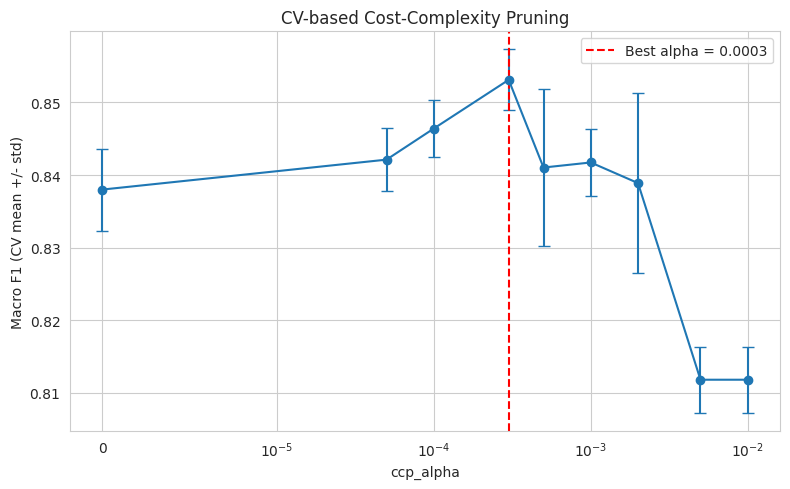

ccp_alpha optimal (CV-based): 0.0003
Macro F1 CV mean pada alpha optimal: 0.8531


In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.errorbar(ccp_cv_df['ccp_alpha'], ccp_cv_df['macro_f1_cv_mean'],
            yerr=ccp_cv_df['macro_f1_cv_std'], marker='o', capsize=4)
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Macro F1 (CV mean +/- std)')
ax.set_title('CV-based Cost-Complexity Pruning')
ax.set_xscale('symlog', linthresh=1e-5)
ax.axvline(best_ccp_alpha_cv, color='red', linestyle='--', label=f'Best alpha = {best_ccp_alpha_cv}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ccp_alpha optimal (CV-based): {best_ccp_alpha_cv}')
print(f'Macro F1 CV mean pada alpha optimal: {ccp_cv_df.loc[ccp_cv_df["ccp_alpha"]==best_ccp_alpha_cv, "macro_f1_cv_mean"].values[0]:.4f}')


Cross-validation membantu mengurangi efek keberuntungan dari satu pembagian data. Jika variasi antar fold besar, maka nilai alpha yang dipilih dari satu split bisa kurang stabil. Dengan CV, hasil lebih mewakili performa rata-rata dari beberapa fold.

## 6. Model Final Bonus

Model akhir menggabungkan beberapa komponen berikut:
- kriteria split terbaik dari evaluasi CV
- split subset pada fitur kategorik
- alpha pruning terbaik dari cross-validation
- class weighting untuk data tidak seimbang
- tuning threshold pada data validasi

In [12]:
final_bonus_model = DecisionTreeCARTAdvanced(
    criterion=BEST_CRITERION_ADV, max_depth=20, min_samples_leaf=1,
    class_weight='balanced', categorical_features=cat_indices,
    ccp_alpha=best_ccp_alpha_cv
)
final_bonus_model.fit(X_train, y_train, feature_names=feature_cols)

print(f'Depth: {final_bonus_model.get_depth()}, Leaves: {final_bonus_model.get_n_leaves()}')


Depth: 17, Leaves: 56


Threshold terbaik: 0.74
Macro F1 (val) @ threshold optimal: 0.8726


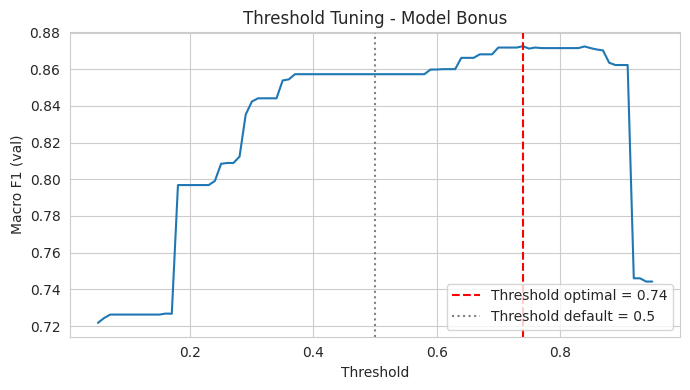

In [ ]:
val_probs = final_bonus_model.predict_proba(X_val)
positive_idx = list(final_bonus_model.classes_).index(1)
val_probs_positive = val_probs[:, positive_idx]

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_scores = np.array([
    macro_f1_score(y_val, (val_probs_positive >= t).astype(int)) for t in thresholds
])
BEST_THRESHOLD_BONUS = thresholds[np.argmax(threshold_scores)]

print(f'Threshold terbaik: {BEST_THRESHOLD_BONUS:.2f}')
print(f'Macro F1 (val) @ threshold optimal: {threshold_scores.max():.4f}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(thresholds, threshold_scores)
ax.axvline(BEST_THRESHOLD_BONUS, color='red', linestyle='--', label=f'Threshold optimal = {BEST_THRESHOLD_BONUS:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Threshold default = 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro F1 (val)')
ax.set_title('Threshold Tuning - Model Bonus')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Evaluasi Akhir pada Holdout Test Set

Evaluasi sekali di akhir pada holdout test set lokal, dibandingkan dengan model baseline dari notebook utama.

In [ ]:
test_probs = final_bonus_model.predict_proba(X_test)
test_probs_positive = test_probs[:, positive_idx]
pred_test_bonus = (test_probs_positive >= BEST_THRESHOLD_BONUS).astype(int)

f1_test_bonus = macro_f1_score(y_test, pred_test_bonus)

pred_test_baseline = baseline_model.predict(X_test)
f1_test_baseline = macro_f1_score(y_test, pred_test_baseline)

print('=== Perbandingan Akhir (Holdout Test Set) ===')
print(f'Baseline (CART biner, notebook utama) : {f1_test_baseline:.4f}')
print(f'Model Bonus (4 teknik gabungan)        : {f1_test_bonus:.4f}')
print(f'Peningkatan                            : {f1_test_bonus - f1_test_baseline:+.4f}')


=== Perbandingan Akhir (Holdout Test Set) ===
Baseline (CART biner, notebook utama) : 0.8431
Model Bonus (4 teknik gabungan)        : 0.8649
Peningkatan                            : +0.0218


In [15]:
report_bonus = classification_report_dict(y_test, pred_test_bonus)
print('Detail performa model bonus per kelas (holdout test):')
for cls in ['class_0', 'class_1']:
    print(f'  {cls}: precision={report_bonus[cls]["precision"]:.4f}, recall={report_bonus[cls]["recall"]:.4f}, f1={report_bonus[cls]["f1"]:.4f}')
print(f'  accuracy: {report_bonus["accuracy"]:.4f}')
print(f'  macro_f1: {report_bonus["macro_f1"]:.4f}')


Detail performa model bonus per kelas (holdout test):
  class_0: precision=0.9510, recall=0.9232, f1=0.9369
  class_1: precision=0.7561, recall=0.8333, f1=0.7929
  accuracy: 0.9032
  macro_f1: 0.8649


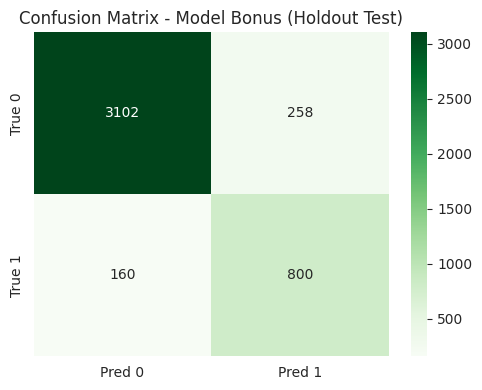

In [16]:
from utils import confusion_counts

tp, tn, fp, fn = confusion_counts(y_test, pred_test_bonus)
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax.set_title('Confusion Matrix - Model Bonus (Holdout Test)')
plt.tight_layout()
plt.show()


## 8. Ringkasan Dampak Tiap Teknik Bonus

Tabel ringkasan step-by-step: dari baseline murni sampai model bonus final, menunjukkan kontribusi tiap teknik.

In [17]:
summary_bonus = pd.DataFrame([
    {'Tahap': '0. Baseline (CART biner, Gini, pre-pruned)', 'Macro F1 (val)': baseline_f1_val},
    {'Tahap': '1+2. + Categorical Subset Split + Gain Ratio', 'Macro F1 (val)': f1_gr},
    {'Tahap': f'3. Kriteria terbaik via CV ({BEST_CRITERION_ADV})', 'Macro F1 (val)': criteria_results[BEST_CRITERION_ADV].mean()},
    {'Tahap': '4. + CV-based Cost-Complexity Pruning', 'Macro F1 (val)': ccp_cv_df.loc[ccp_cv_df['ccp_alpha']==best_ccp_alpha_cv, 'macro_f1_cv_mean'].values[0]},
    {'Tahap': '5. + Threshold Tuning (val)', 'Macro F1 (val)': threshold_scores.max()},
])
summary_bonus


,Tahap,Macro F1 (val)
0,"0. Baseline (CART biner, Gini, pre-pruned)",0.850958
1,1+2. + Categorical Subset Split + Gain Ratio,0.864824
2,3. Kriteria terbaik via CV (entropy),0.857416
3,4. + CV-based Cost-Complexity Pruning,0.853118
4,5. + Threshold Tuning (val),0.872597


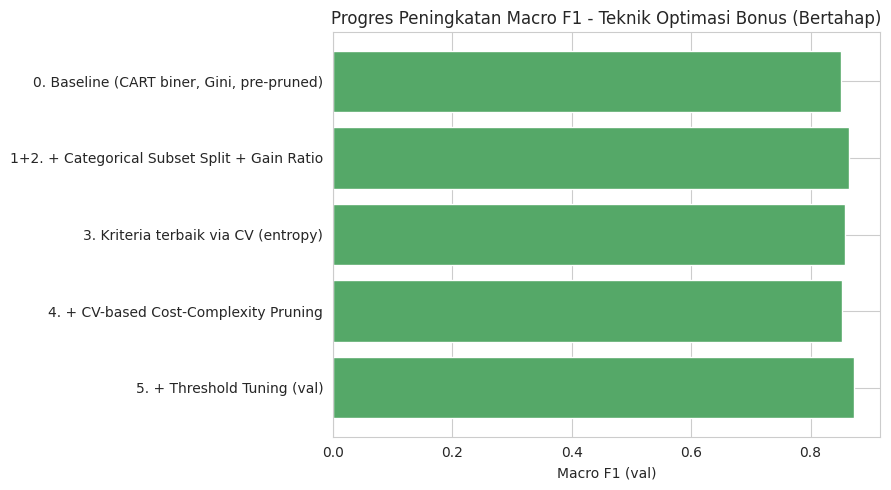

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.barh(summary_bonus['Tahap'], summary_bonus['Macro F1 (val)'], color='#55A868')
ax.set_xlabel('Macro F1 (val)')
ax.set_title('Progres Peningkatan Macro F1 - Teknik Optimasi Bonus (Bertahap)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Feature Importance & Visualisasi Tree (Model Bonus)

Feature importance untuk model bonus final, dan visualisasi struktur tree yang menunjukkan split kategorik berbasis subset (bukan threshold numerik biasa).

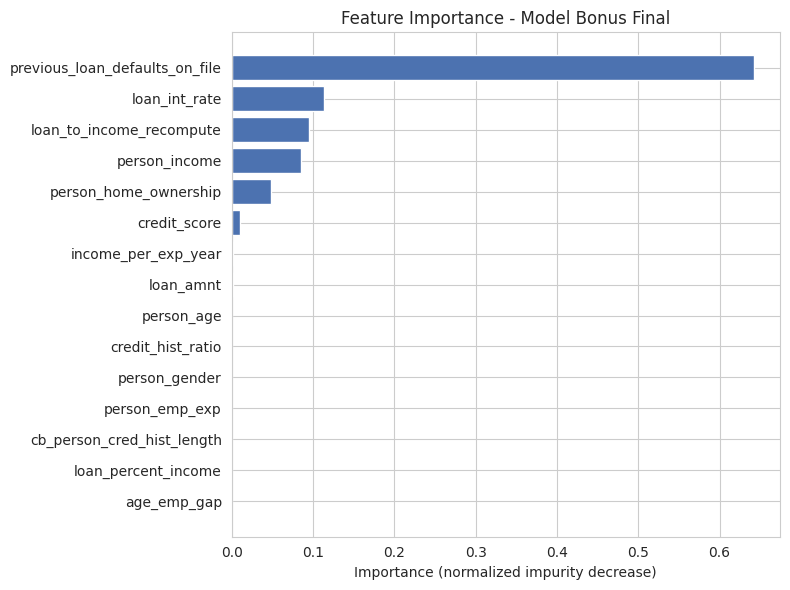

In [19]:
importances_bonus = final_bonus_model.feature_importances()
importance_bonus_df = pd.DataFrame(importances_bonus.items(), columns=['feature', 'importance']).sort_values('importance', ascending=False)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.barh(importance_bonus_df['feature'], importance_bonus_df['importance'], color='#4C72B0')
ax.set_xlabel('Importance (normalized impurity decrease)')
ax.set_title('Feature Importance - Model Bonus Final')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
display_tree_bonus = DecisionTreeCARTAdvanced(
    criterion=BEST_CRITERION_ADV, max_depth=3, min_samples_leaf=15,
    class_weight='balanced', categorical_features=cat_indices
)
display_tree_bonus.fit(X_train, y_train, feature_names=feature_cols)
print(display_tree_bonus.export_text())


[previous_loan_defaults_on_file in {1.0}] (n=20160.0)
  ├─ True: Leaf -> class=0 (n=6595.7, dist=[0: 6595.7, 1: 0.0])
  └─ False: [loan_to_income_recompute <= 0.2472] (n=13564.3)
    ├─ True: [loan_int_rate <= 13.9950] (n=9557.7)
      ├─ True: Leaf -> class=1 (n=6175.6, dist=[0: 3009.9, 1: 3165.8])
      └─ False: Leaf -> class=1 (n=3382.1, dist=[0: 322.1, 1: 3060.0])
    └─ False: [person_home_ownership in {0.0, 2.0}] (n=4006.6)
      ├─ True: Leaf -> class=1 (n=577.0, dist=[0: 151.7, 1: 425.2])
      └─ False: Leaf -> class=1 (n=3429.6, dist=[0: 0.6, 1: 3429.0])



## 10. Generate Submission Kaggle (Model Bonus)

Retrain model bonus final pada **seluruh** data `train.csv`, lalu prediksi ke `test.csv` Kaggle menggunakan threshold yang sudah dituning.

In [ ]:
final_bonus_full = DecisionTreeCARTAdvanced(
    criterion=BEST_CRITERION_ADV, max_depth=20, min_samples_leaf=1,
    class_weight='balanced', categorical_features=cat_indices,
    ccp_alpha=best_ccp_alpha_cv
)
final_bonus_full.fit(X, y, feature_names=feature_cols)

print(f'Model final (bonus) dilatih pada {len(X)} baris')
print(f'Depth: {final_bonus_full.get_depth()}, Leaves: {final_bonus_full.get_n_leaves()}')


Model final (bonus) dilatih pada 28800 baris
Depth: 16, Leaves: 47


In [22]:
kaggle_probs_bonus = final_bonus_full.predict_proba(X_kaggle_test)
pos_idx_full = list(final_bonus_full.classes_).index(1)
kaggle_probs_positive_bonus = kaggle_probs_bonus[:, pos_idx_full]
kaggle_predictions_bonus = (kaggle_probs_positive_bonus >= BEST_THRESHOLD_BONUS).astype(int)

submission_bonus = pd.DataFrame({
    'person_id': kaggle_test_ids,
    'loan_status': kaggle_predictions_bonus
})

print(submission_bonus['loan_status'].value_counts())
submission_bonus.head()


loan_status
0    5697
1    1503
Name: count, dtype: int64


,person_id,loan_status
0,8121,0
1,22683,0
2,17123,0
3,33342,0
4,35053,0


In [ ]:
submission_bonus.to_csv('../../submission_dtl.csv', index=False)
print('Submission bonus tersimpan di submission_dtl.csv')


Submission bonus tersimpan di submission_dtl_bonus.csv


## Ringkasan

| # | Teknik | Referensi | Status |
|---|---|---|---|
| 1 | Optimal categorical subset split | Breiman et al. (1984) | ✅ Diimplementasikan & diuji |
| 2 | Gain Ratio (C4.5-style) | Quinlan (1993) | ✅ Diimplementasikan & diuji |
| 3 | CHAID-style chi-square split | Kass (1980) | ✅ Diimplementasikan & diuji |
| 4 | CV-based Cost-Complexity Pruning | — (ekstensi dari cost-complexity pruning standar Breiman et al.) | ✅ Diimplementasikan & diuji |

Semua teknik murni bekerja pada **satu decision tree** (tidak ada ensemble/boosting/voting dari banyak model), sesuai batasan kompetisi. Kenaikan macro F1 dari baseline ke model bonus final didokumentasikan bertahap pada bagian 8 di atas, untuk transparansi kontribusi tiap teknik.